#### ViT 스크래치 코드

하이퍼파라미터 설정

In [11]:
import os, torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from torch.nn import functional as F
import torchvision
import torchvision.transforms as transforms

# 1. 하이퍼파라미터 설정
batch_size = 128        # 범위(32~128),
learning_rate = 1e-4    # Adam 추천값(0.001~0.0001)
epochs = 50             # 범위(10~50) 
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 모델 아키텍처 사이즈  
img_size = 96
patch_size = 16
n_embd = 256     	# 표현력 (n_head=8로 나눠떨어짐)
n_head = 8
num_blks = 6     	
emb_dropout = blk_dropout = 0.2   
num_classes = 10  	# CIFAR-10이므로 10개 클래스


CIFAR-10 데이터셋 로드

데이터셋을 다운로드하고 준비합니다...


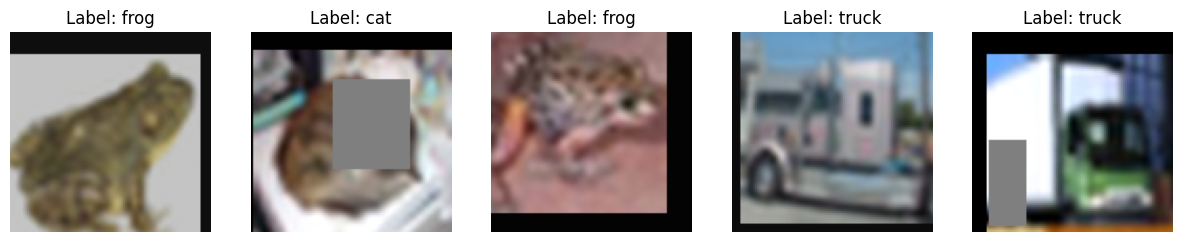

In [ ]:
# CIFAR-10 원본은 32x32 사이즈지만, 우리가 만든 VLM 구조(96x96)와
# 완벽하게 호환시키기 위해 Resize(96)을 적용.
# 학습 데이터에는 데이터 증강(Augmentation)을 추가하여 일반화 성능 향상
train_transform = transforms.Compose([
	# CIFAR-10(32x32)을 96x96으로 업스케일: LANCZOS 보간으로 경계(edge) 흐림 최소화
	transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.LANCZOS),
	transforms.RandomCrop(img_size, padding=12),     # [개선] 패딩 후 랜덤 크롭: 위치 변화에 강건
	transforms.RandomHorizontalFlip(p=0.5),         # 좌우 반전
	transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 색상 증강
	transforms.ToTensor(),
	transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
	transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),  # [개선] 랜덤 패치 제거: 특정 영역 과의존 방지
])

# 테스트 데이터는 증강 없이 원본 그대로 사용 (동일한 LANCZOS 보간 적용)
test_transform = transforms.Compose([
	transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.LANCZOS),
	transforms.ToTensor(),
	transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("데이터셋을 다운로드하고 준비합니다...")
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 데이터셋 샘플 몇개 저장
dataiter = iter(trainloader)
images, labels = next(dataiter)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
	img = images[i].numpy()
	img = img * 0.5 + 0.5
	img = np.transpose(img, (1, 2, 0))
	axes[i].imshow(img)
	axes[i].set_title(f"Label: {classes[labels[i]]}")
	axes[i].axis('off')
	
ouptut_fname = "./cifar10_samples.png"
plt.savefig(ouptut_fname)
plt.show()


ViT 모델 구조 정의 (VLM 확장을 위한 뼈대)

In [13]:
# 이미지 패치를 임베딩 
class PatchEmbeddings(nn.Module):
	def __init__(self, img_size, patch_size, hidden_dim):
		super().__init__()
		self.conv = nn.Conv2d(in_channels=3, out_channels=hidden_dim, kernel_size=patch_size, stride=patch_size)

	def forward(self, X):
		X = self.conv(X)            # shape = (B, hidden_dim, H/patch_size, W/patch_size). (128, 256, 6, 6)
		X = X.flatten(2)            # flatten(2) means flattening the last two dimensions. shape = (128, 256, 36)
		X = X.transpose(1, 2)       # shape = (128, 36, 256)
		return X

patch_emb = PatchEmbeddings(img_size, patch_size, n_embd).to(device)
print("입력 이미지 크기:", images.shape)
print("패치 임베딩 출력 크기:", patch_emb.forward(images.to(device)).shape)

입력 이미지 크기: torch.Size([128, 3, 96, 96])
패치 임베딩 출력 크기: torch.Size([128, 36, 256])


In [14]:
# 트랜스포머 블록 구성 요소
class Head(nn.Module): # 단일 어텐션 헤드
	def __init__(self, n_embd, head_size, dropout=0.1, is_decoder=False):
		super().__init__()
		self.key = nn.Linear(n_embd, head_size, bias=False)  	# 키 벡터 생성
		self.query = nn.Linear(n_embd, head_size, bias=False) 	# 쿼리 벡터 생성
		self.value = nn.Linear(n_embd, head_size, bias=False)	# 값 벡터 생성
		self.dropout = nn.Dropout(dropout)		# 어텐션 가중치 드롭아웃
		self.is_decoder = is_decoder 			# 디코더 모드에서는 미래 토큰을 마스킹하여 자기회귀적 예측이 가능하도록 함

	def forward(self, x):
		B, T, C = x.shape       # shape = (B, T, C). (128, 37, 256)
		k = self.key(x)         # shape = (B, T, n_embd // n_head). (128, 37, 32)
		q = self.query(x)
		v = self.value(x)
		wei = q @ k.transpose(-2, -1) * (C**-0.5) # 유사도 계산 및 스케일링. shape = (B, T, T). (128, 37, 37)

		if self.is_decoder:
			tril = torch.tril(torch.ones(T, T, dtype=torch.bool, device=device))
			wei = wei.masked_fill(tril == 0, float('-inf'))
			
		wei = F.softmax(wei, dim=-1)
		wei = self.dropout(wei)
		return wei @ v

class MultiHeadAttention(nn.Module): # 멀티헤드 어텐션
	def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
		super().__init__()
		assert n_embd % num_heads == 0, "n_embd must be divisible by num_heads" # 각 헤드가 동일한 차원을 갖도록 보장
		self.heads = nn.ModuleList([Head(n_embd, n_embd // num_heads, dropout, is_decoder) for _ in range(num_heads)])
		self.proj = nn.Linear(n_embd, n_embd) # 멀티헤드 어텐션 출력을 원래 임베딩 차원으로 투영
		self.dropout = nn.Dropout(dropout)	

	def forward(self, x):
		out = torch.cat([h(x) for h in self.heads], dim=-1) # 각 헤드의 출력을 연결하여 최종 어텐션 출력 생성. shape = (B, T, n_embd). (128, 37, 256)
		return self.dropout(self.proj(out)) # shape = (B, T, n_embd). (128, 37, 256)

class Block(nn.Module): # 트랜스포머 블록 (멀티헤드 어텐션 + 피드포워드 네트워크)
	def __init__(self, n_embd, num_heads, dropout=0.1, is_decoder=False):
		super().__init__()
		self.ln1 = nn.LayerNorm(n_embd) # 어텐션 전에 레이어 정규화
		self.attn = MultiHeadAttention(n_embd, num_heads, dropout, is_decoder) # 멀티헤드 어텐션
		self.ln2 = nn.LayerNorm(n_embd) # 피드포워드 네트워크 전에 레이어 정규화
		self.ffn = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd)) # 피드포워드 네트워크
	def forward(self, x):
		x = x + self.attn(self.ln1(x))  # 잔차 연결을 통해 어텐션 출력과 입력을 더함. shape = (B, T, n_embd). (128, 37, 256)
		x = x + self.ffn(self.ln2(x))   # 잔차 연결을 통해 피드포워드 출력과 입력을 더함. shape = (B, T, n_embd). (128, 37, 256)
		return x

class ViT(nn.Module): # 비전 트랜스포머 모델
	def __init__(self, img_size, patch_size, num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout, num_classes):
		super().__init__()
		self.patch_embedding = PatchEmbeddings(img_size, patch_size, num_hiddens) 	# 이미지 패치를 임베딩 벡터로 변환
		self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))				# 클래스 토큰 초기화 (학습 가능한 파라미터)
		num_patches = (img_size // patch_size) ** 2
		self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, num_hiddens)) 	# 위치 임베딩 초기화 (학습 가능한 파라미터)
		self.dropout = nn.Dropout(emb_dropout)										
		
		self.blocks = nn.ModuleList([Block(num_hiddens, num_heads, blk_dropout, is_decoder=False) for _ in range(num_blks)]) # 트랜스포머 블록 여러 개 쌓기
		self.layer_norm = nn.LayerNorm(num_hiddens) # 최종 레이어 정규화
		self.classifier = nn.Linear(num_hiddens, num_classes) # 분류기(클래스 토큰을 최종적으로 클래스 확률로 변환)

	def forward(self, X):
		x = self.patch_embedding(X)     # shape = (B, num_patches, num_hiddens) from patch embedding. (128, 3, 96, 96) -> (128, 36, 256)
		cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)  # shape = (B, 1, 256)
		x = torch.cat((cls_tokens, x), dim=1)                   # shape = (B, num_patches + 1, num_hiddens). (128, 37, 256) 
		x += self.pos_embedding     # 위치 임베딩 추가. 초기값은 랜덤이지만 학습을 통해 최적화됨. (128, 37, 256)
		x = self.dropout(x)
		
		for block in self.blocks:
			x = block(x)
			
		cls_output = self.layer_norm(x[:, 0])   # 클래스 토큰의 최종 표현을 추출 (shape = (B, num_hiddens). (128, 256))
		logits = self.classifier(cls_output) 	# 클래스 토큰을 최종적으로 클래스 확률로 변환 (shape = (B, num_classes). (128, 10))
		return logits 

model_net = ViT(img_size, patch_size, n_embd, n_head, num_blks, emb_dropout, blk_dropout, num_classes).to(device)
model_net.forward(images.to(device))

tensor([[ 0.6226, -0.4218,  0.6079,  ..., -0.1201,  1.0369,  0.5003],
        [ 0.5540, -0.1947,  0.6941,  ..., -0.0422,  0.6450,  0.4030],
        [ 0.3326, -0.0878,  0.3086,  ..., -0.5944,  0.9689,  0.2729],
        ...,
        [ 0.5307, -0.3483,  1.0314,  ...,  0.2179,  0.7537,  0.2610],
        [ 0.7476, -0.8026,  0.4962,  ..., -0.4967,  0.9222,  0.2954],
        [ 0.1271, -0.2825,  0.0294,  ..., -0.4063,  0.9189,  0.1340]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

학습 루프 및 검증 코드 정의

In [ ]:
print(f"1. 모델 초기화 (디바이스: {device})")
model = ViT(img_size, patch_size, n_embd, n_head, num_blks, emb_dropout, blk_dropout, num_classes).to(device)
# Adam에 weight decay 추가 (일반화 성능 향상)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss() 

# [개선] CosineAnnealingLR: 코사인 곡선으로 학습률 감소 → ReduceLROnPlateau 대비 안정적 수렴
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

print("2. CIFAR-10 학습 시작")
best_val_loss = float('inf')
patience = 10  # [개선] 3→10: 코사인 스케줄러 환경에서 일시적 val loss 증가 허용
patience_counter = 0
for epoch in range(epochs):
	model.train()
	running_loss = 0.0
	for i, data in enumerate(trainloader, 0):
		inputs, labels = data
		inputs, labels = inputs.to(device), labels.to(device)

		optimizer.zero_grad()
		outputs = model(inputs)
		loss = criterion(outputs, labels)
		loss.backward()
		optimizer.step()

		running_loss += loss.item()
		# 100 미니배치마다 로그 출력
		if i % 100 == 99:    
			print(f"[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}")
			running_loss = 0.0

	# validation loss 계산 (테스트 데이터 사용)
	model.eval()
	val_loss = 0.0
	with torch.no_grad():
		for val_inputs, val_labels in testloader:
			val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
			val_outputs = model(val_inputs)
			val_loss += criterion(val_outputs, val_labels).item()
	val_loss /= len(testloader)
	print(f"[Epoch {epoch + 1}] Validation Loss: {val_loss:.4f}")
	
	# CosineAnnealingLR 스케줄러 업데이트 (매 epoch 호출)
	scheduler.step()

	# early stopping
	if val_loss < best_val_loss:
		best_val_loss = val_loss
		patience_counter = 0
		# 모델 저장 (optional)
		torch.save(model.state_dict(), 'best_vit_model.pth')
	else:
		patience_counter += 1
		if patience_counter >= patience:
			print("Early stopping triggered.")
			break


1. 모델 초기화 (디바이스: cuda)
2. CIFAR-10 학습 시작
[Epoch 1, Batch 100] Loss: 2.161
[Epoch 1, Batch 200] Loss: 2.026
[Epoch 1, Batch 300] Loss: 1.967
[Epoch 1] Validation Loss: 1.8028
[Epoch 2, Batch 100] Loss: 1.856
[Epoch 2, Batch 200] Loss: 1.797
[Epoch 2, Batch 300] Loss: 1.745
[Epoch 2] Validation Loss: 1.5702
[Epoch 3, Batch 100] Loss: 1.681
[Epoch 3, Batch 200] Loss: 1.635
[Epoch 3, Batch 300] Loss: 1.621
[Epoch 3] Validation Loss: 1.4663
[Epoch 4, Batch 100] Loss: 1.579
[Epoch 4, Batch 200] Loss: 1.532
[Epoch 4, Batch 300] Loss: 1.534
[Epoch 4] Validation Loss: 1.3940
[Epoch 5, Batch 100] Loss: 1.507
[Epoch 5, Batch 200] Loss: 1.492
[Epoch 5, Batch 300] Loss: 1.465
[Epoch 5] Validation Loss: 1.3508
[Epoch 6, Batch 100] Loss: 1.455
[Epoch 6, Batch 200] Loss: 1.436
[Epoch 6, Batch 300] Loss: 1.441
[Epoch 6] Validation Loss: 1.3298
[Epoch 7, Batch 100] Loss: 1.401
[Epoch 7, Batch 200] Loss: 1.415
[Epoch 7, Batch 300] Loss: 1.399
[Epoch 7] Validation Loss: 1.3040
[Epoch 8, Batch 100] Loss: 1

학습 모델 데이터 예측


[예측 결과 샘플 확인]
정답: cat -> 모델 예측: cat
정답: ship -> 모델 예측: ship
정답: ship -> 모델 예측: plane
정답: plane -> 모델 예측: plane
정답: frog -> 모델 예측: frog


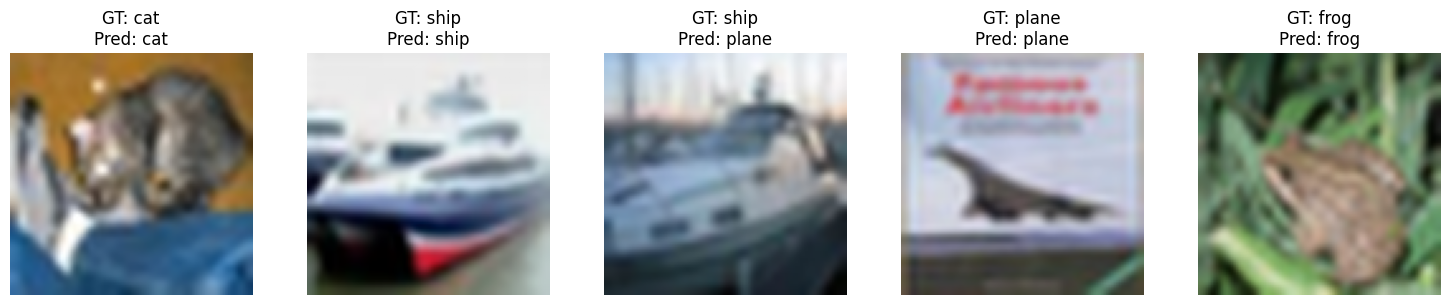

In [16]:
print("\n[예측 결과 샘플 확인]")
model.load_state_dict(torch.load('best_vit_model.pth'))
model.eval()

# 테스트 로더에서 딱 1개의 배치만 가져오기
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

# 결과 시각화 (5개만)
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for j in range(5):
    img = images[j].cpu().numpy()
    img = img * 0.5 + 0.5  # 정규화 해제 (Unnormalize)
    img = np.transpose(img, (1, 2, 0))

    axes[j].imshow(img)
    axes[j].set_title(f"GT: {classes[labels[j]]}\nPred: {classes[predicted[j]]}")
    axes[j].axis('off')
    print(f"정답: {classes[labels[j]]} -> 모델 예측: {classes[predicted[j]]}")

plt.tight_layout()
output_fname = "./vit_prediction_samples.png"
plt.savefig(output_fname) 
plt.show()